### **CARGA DE GOOGLE DRIVE**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **CARGA DE LOS DATOS**

In [2]:
import pandas as pd
import os

# Ruta carpeta
ruta_carpeta = "/content/drive/MyDrive/DATOSTFG"
ruta_archivo = os.path.join(ruta_carpeta, "Dataset_TFG.xlsx")

# Cargar dataset
df = pd.read_excel(ruta_archivo)

Se procede a eliminar las columnas irrelavantes para el proyecto.

In [3]:
# Columnas a conservar
columnas_estudio = [
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Contract',
    'Paperless Billing',
    'Payment Method',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Monthly Charges',
    'Total Charges',
    'Churn Value'
]

df = df[columnas_estudio].copy()

# Comprobación
print("Dimensión tras seleccionar variables:", df.shape)
print("Columnas actuales:")
print(df.columns.tolist())

Dimensión tras seleccionar variables: (7043, 19)
Columnas actuales:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Contract', 'Paperless Billing', 'Payment Method', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Monthly Charges', 'Total Charges', 'Churn Value']


Se renombran las columnas para evitar los espacios y evitar problemas con la lectura del dataframe.

In [4]:
df = df.rename(columns={
    'Senior Citizen': 'SeniorCitizen',
    'Tenure Months': 'Tenure',
    'Paperless Billing': 'PaperlessBilling',
    'Payment Method': 'PaymentMethod',
    'Phone Service': 'PhoneService',
    'Multiple Lines': 'MultipleLines',
    'Internet Service': 'InternetService',
    'Online Security': 'OnlineSecurity',
    'Online Backup': 'Backup',
    'Tech Support': 'TechSupport',
    'Streaming TV': 'StreamingTV',
    'Streaming Movies': 'StreamingMovies',
    'Monthly Charges': 'MonthlyCharges',
    'Total Charges': 'TotalCharges',
    'Churn Value': 'churn'
})

Se comprueba el tipo de dato de cada columna y el número de valor nulos en cada una.

In [5]:
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

Tipos de datos:
Gender               object
SeniorCitizen        object
Partner              object
Dependents           object
Tenure                int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
Backup               object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MonthlyCharges      float64
TotalCharges         object
churn                 int64
dtype: object

Valores nulos por columna:
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
Contract            0
PaperlessBilling    0
PaymentMethod       0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
Backup              0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MonthlyCharges      0
TotalCharges        0
churn         

Se ha visto que la columna TotalCharges se identifica como categórica cuando en realidad es numérica. Se cambia el tipo y se comprueba que no se hayan generado valores nulos.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Valores nulos en TotalCharges tras convertir:")
print(df['TotalCharges'].isnull().sum())

Valores nulos en TotalCharges tras convertir:
11


Al aparecer algún valor nulo en dicha columna, se realiza una imputación directa. En el caso de las variables numéricas se imputa la media, mientras que en el caso de las categóricas se imputa la moda. De esta manera no se modifica la distribución de las variables.

In [7]:
import numpy as np

# Columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Columnas categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Imputación numéricas con media
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].mean())

# Imputación categóricas con moda
for col in columnas_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Nulos después del tratamiento:")
print(df.isnull().sum())

Nulos después del tratamiento:
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
Contract            0
PaperlessBilling    0
PaymentMethod       0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
Backup              0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MonthlyCharges      0
TotalCharges        0
churn               0
dtype: int64


### **DESBALANCEO DE CLASES**

Se comprueba que hay un desbalanceo en el número de registros de la variable objetivo. Posteriomente se estudiará la téncica para solucionar este problema.

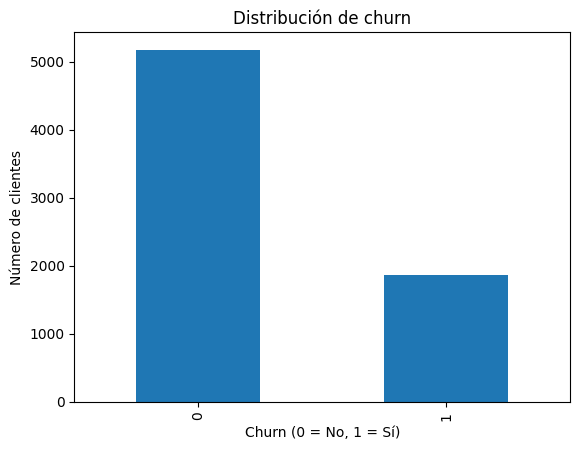

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(kind='bar')
plt.title("Distribución de churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Número de clientes")
plt.show()
print(df['churn'].value_counts(normalize=True))

### **BOXPLOTS**

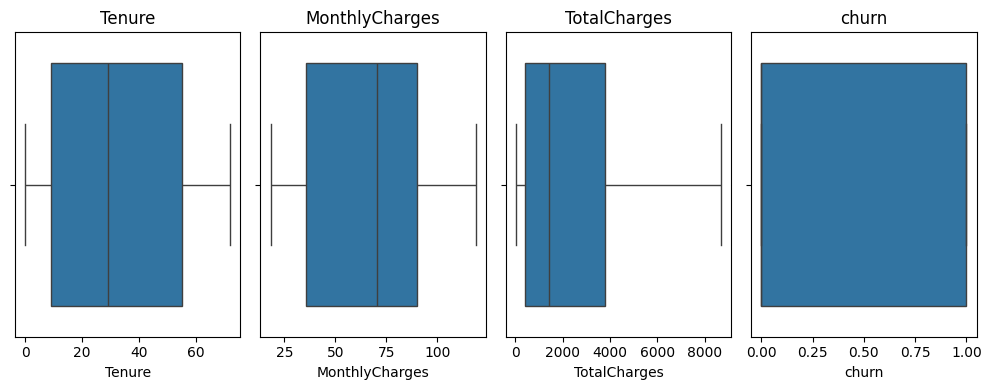

In [9]:
import seaborn as sns
n = len(columnas_numericas)

plt.figure(figsize=(10, 4))

for i, col in enumerate(columnas_numericas):
    plt.subplot(1, n, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Se obtienen las medidas de las varaibles numéricas.

In [10]:
df[['Tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2265.000258
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1400.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


En el caso de las variables categóricas se obtiene el número de registros por clase.

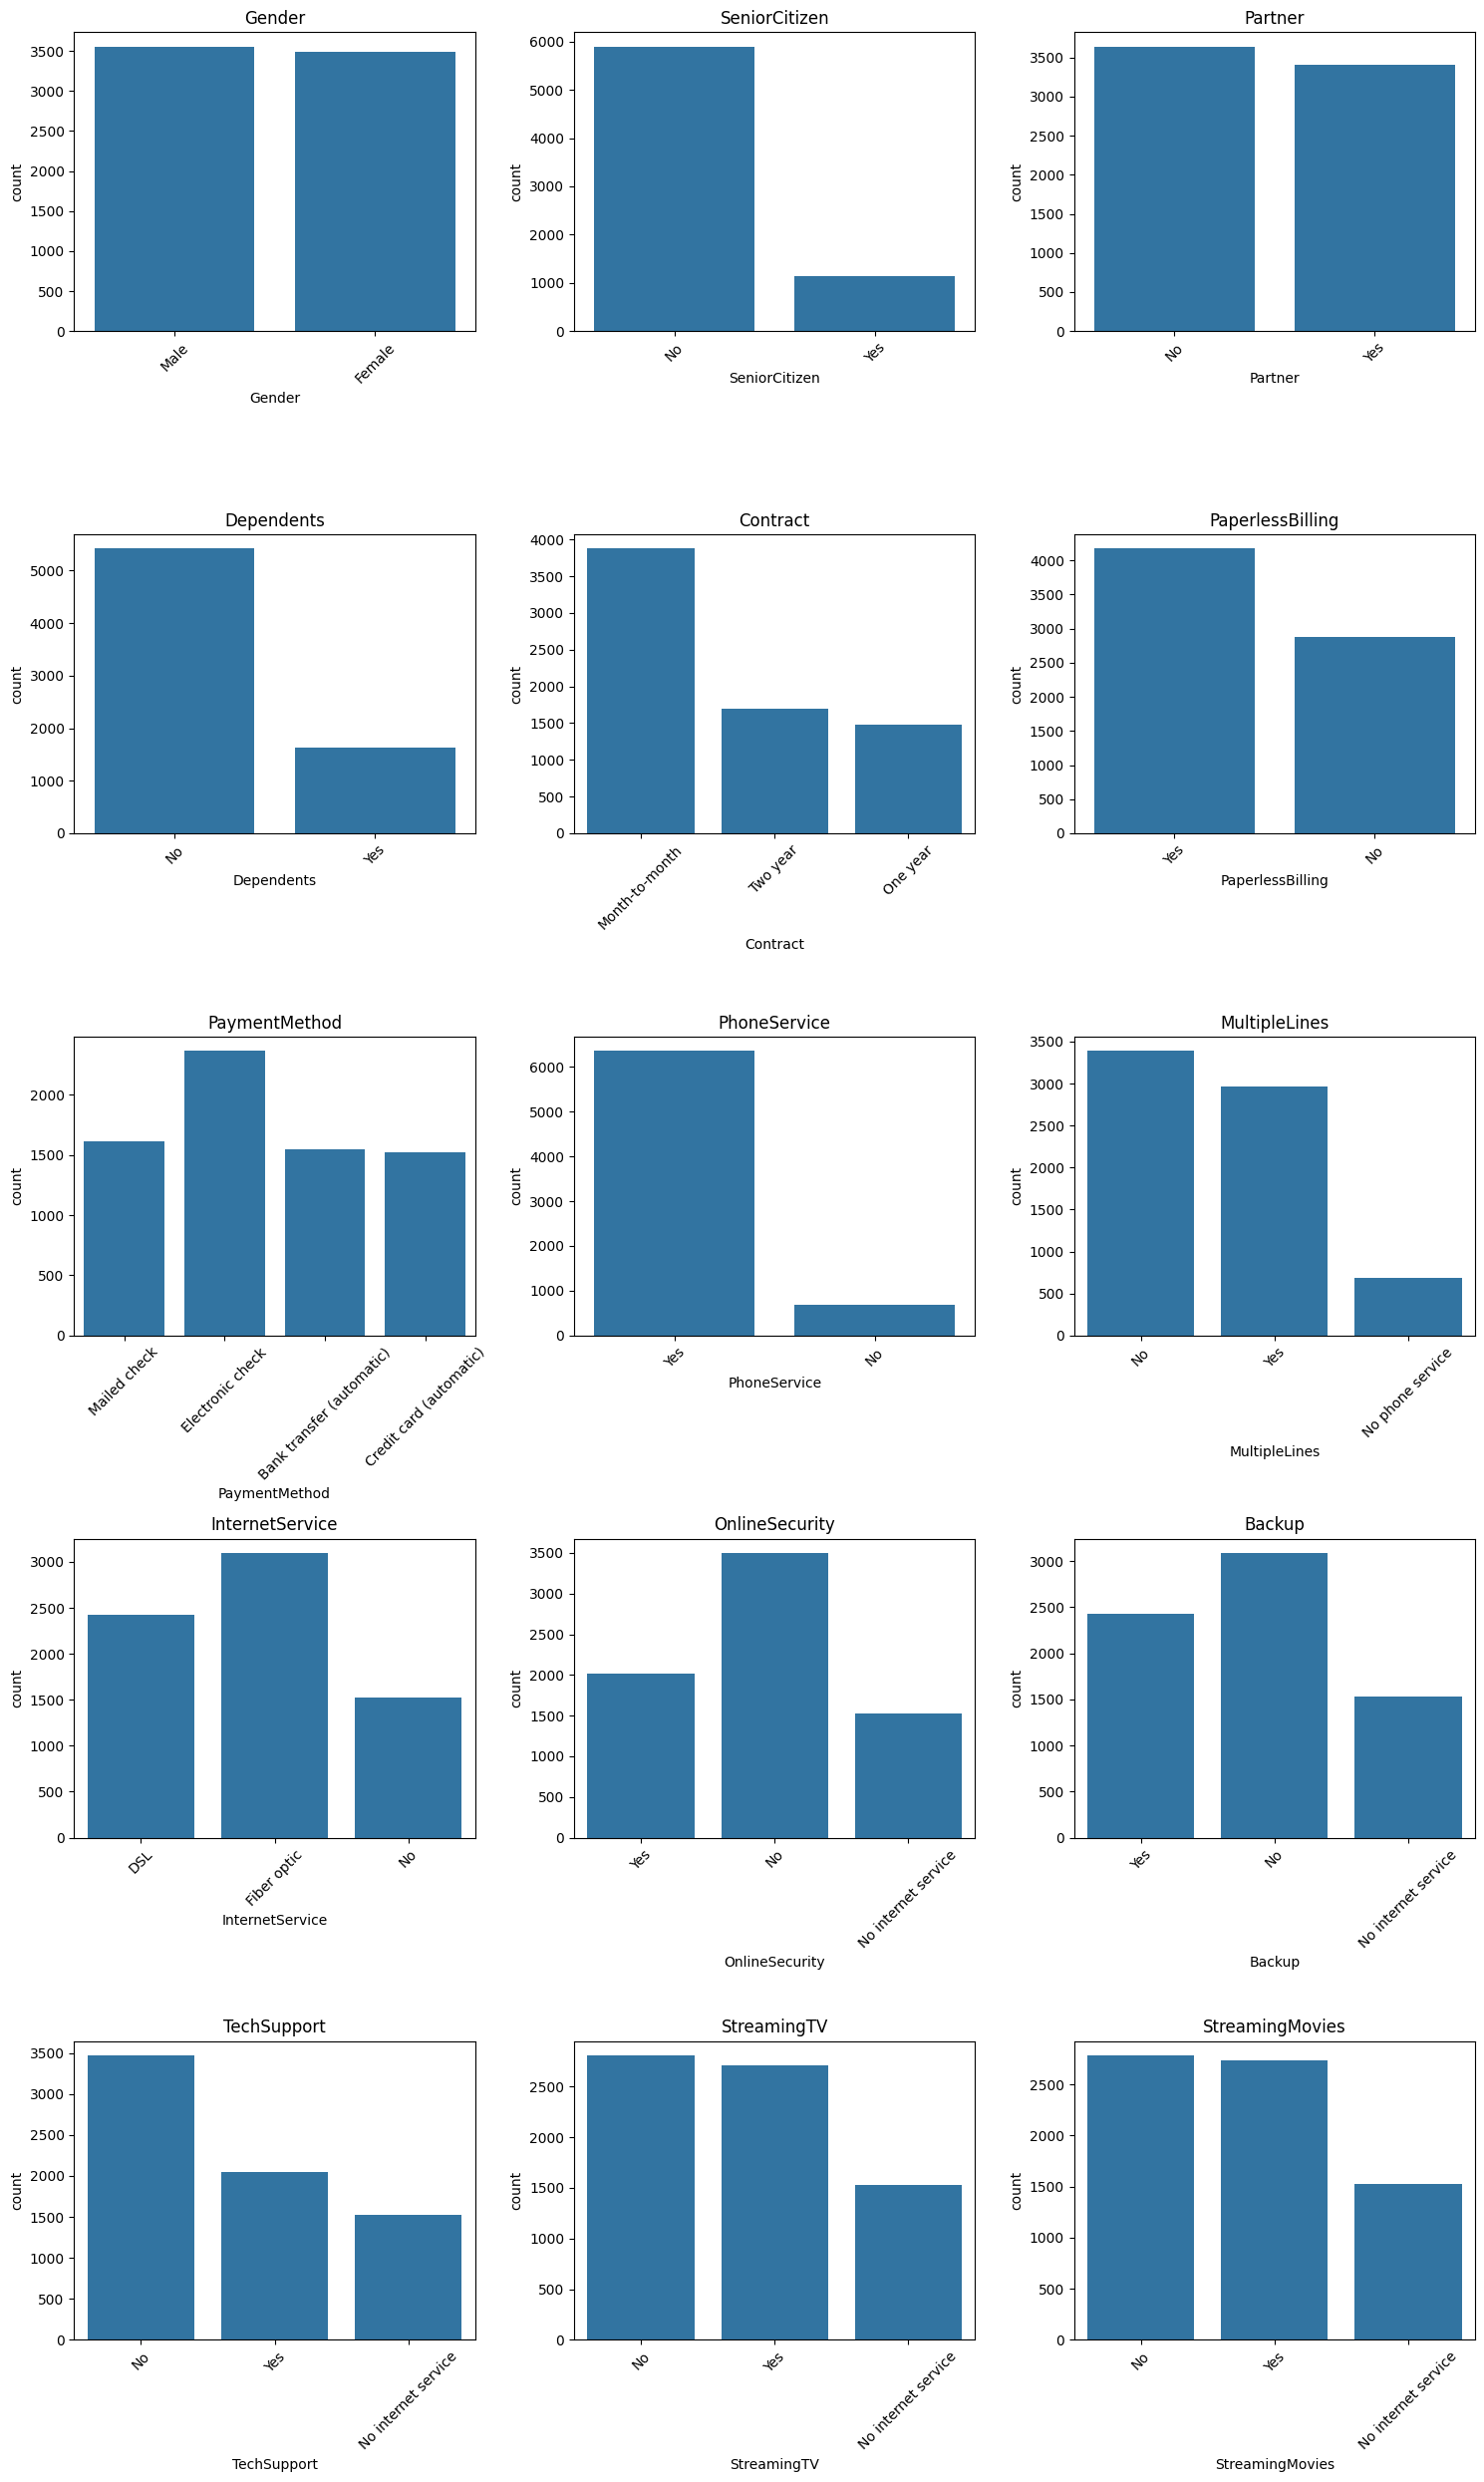

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables categóricas
columnas_categoricas = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'Backup', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Configuración de subplots
n_cols = 3
n_rows = (len(columnas_categoricas) + 2) // 3

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(columnas_categoricas):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- PaperlessBilling ---
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService


### **MATRIZ DE CORRELACIÓN**
Se obteiene la matriz de correlación de las varaibles numéricas para identificar cuál puede tener impacto en la variable objetivo.

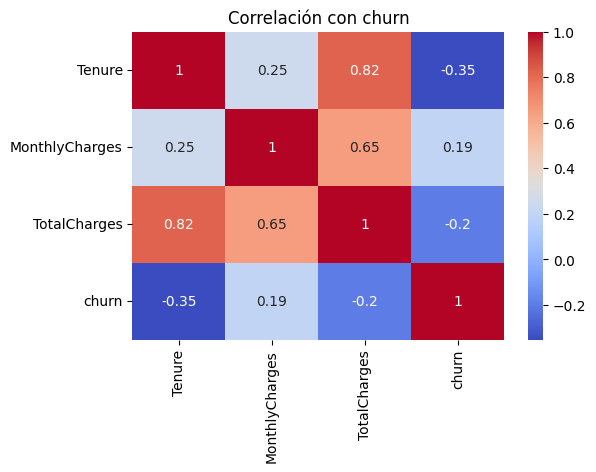

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_numericas = ['Tenure', 'MonthlyCharges', 'TotalCharges']

corr = df[columnas_numericas + ['churn']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlación con churn")
plt.show()

En el caso de las variables categóricas, se estudia si las clases tienen diferente porcentaje de tasa de abandono para poder identificar aquellas en las que influya la clase para saber si hay más tasa de abandono o no.

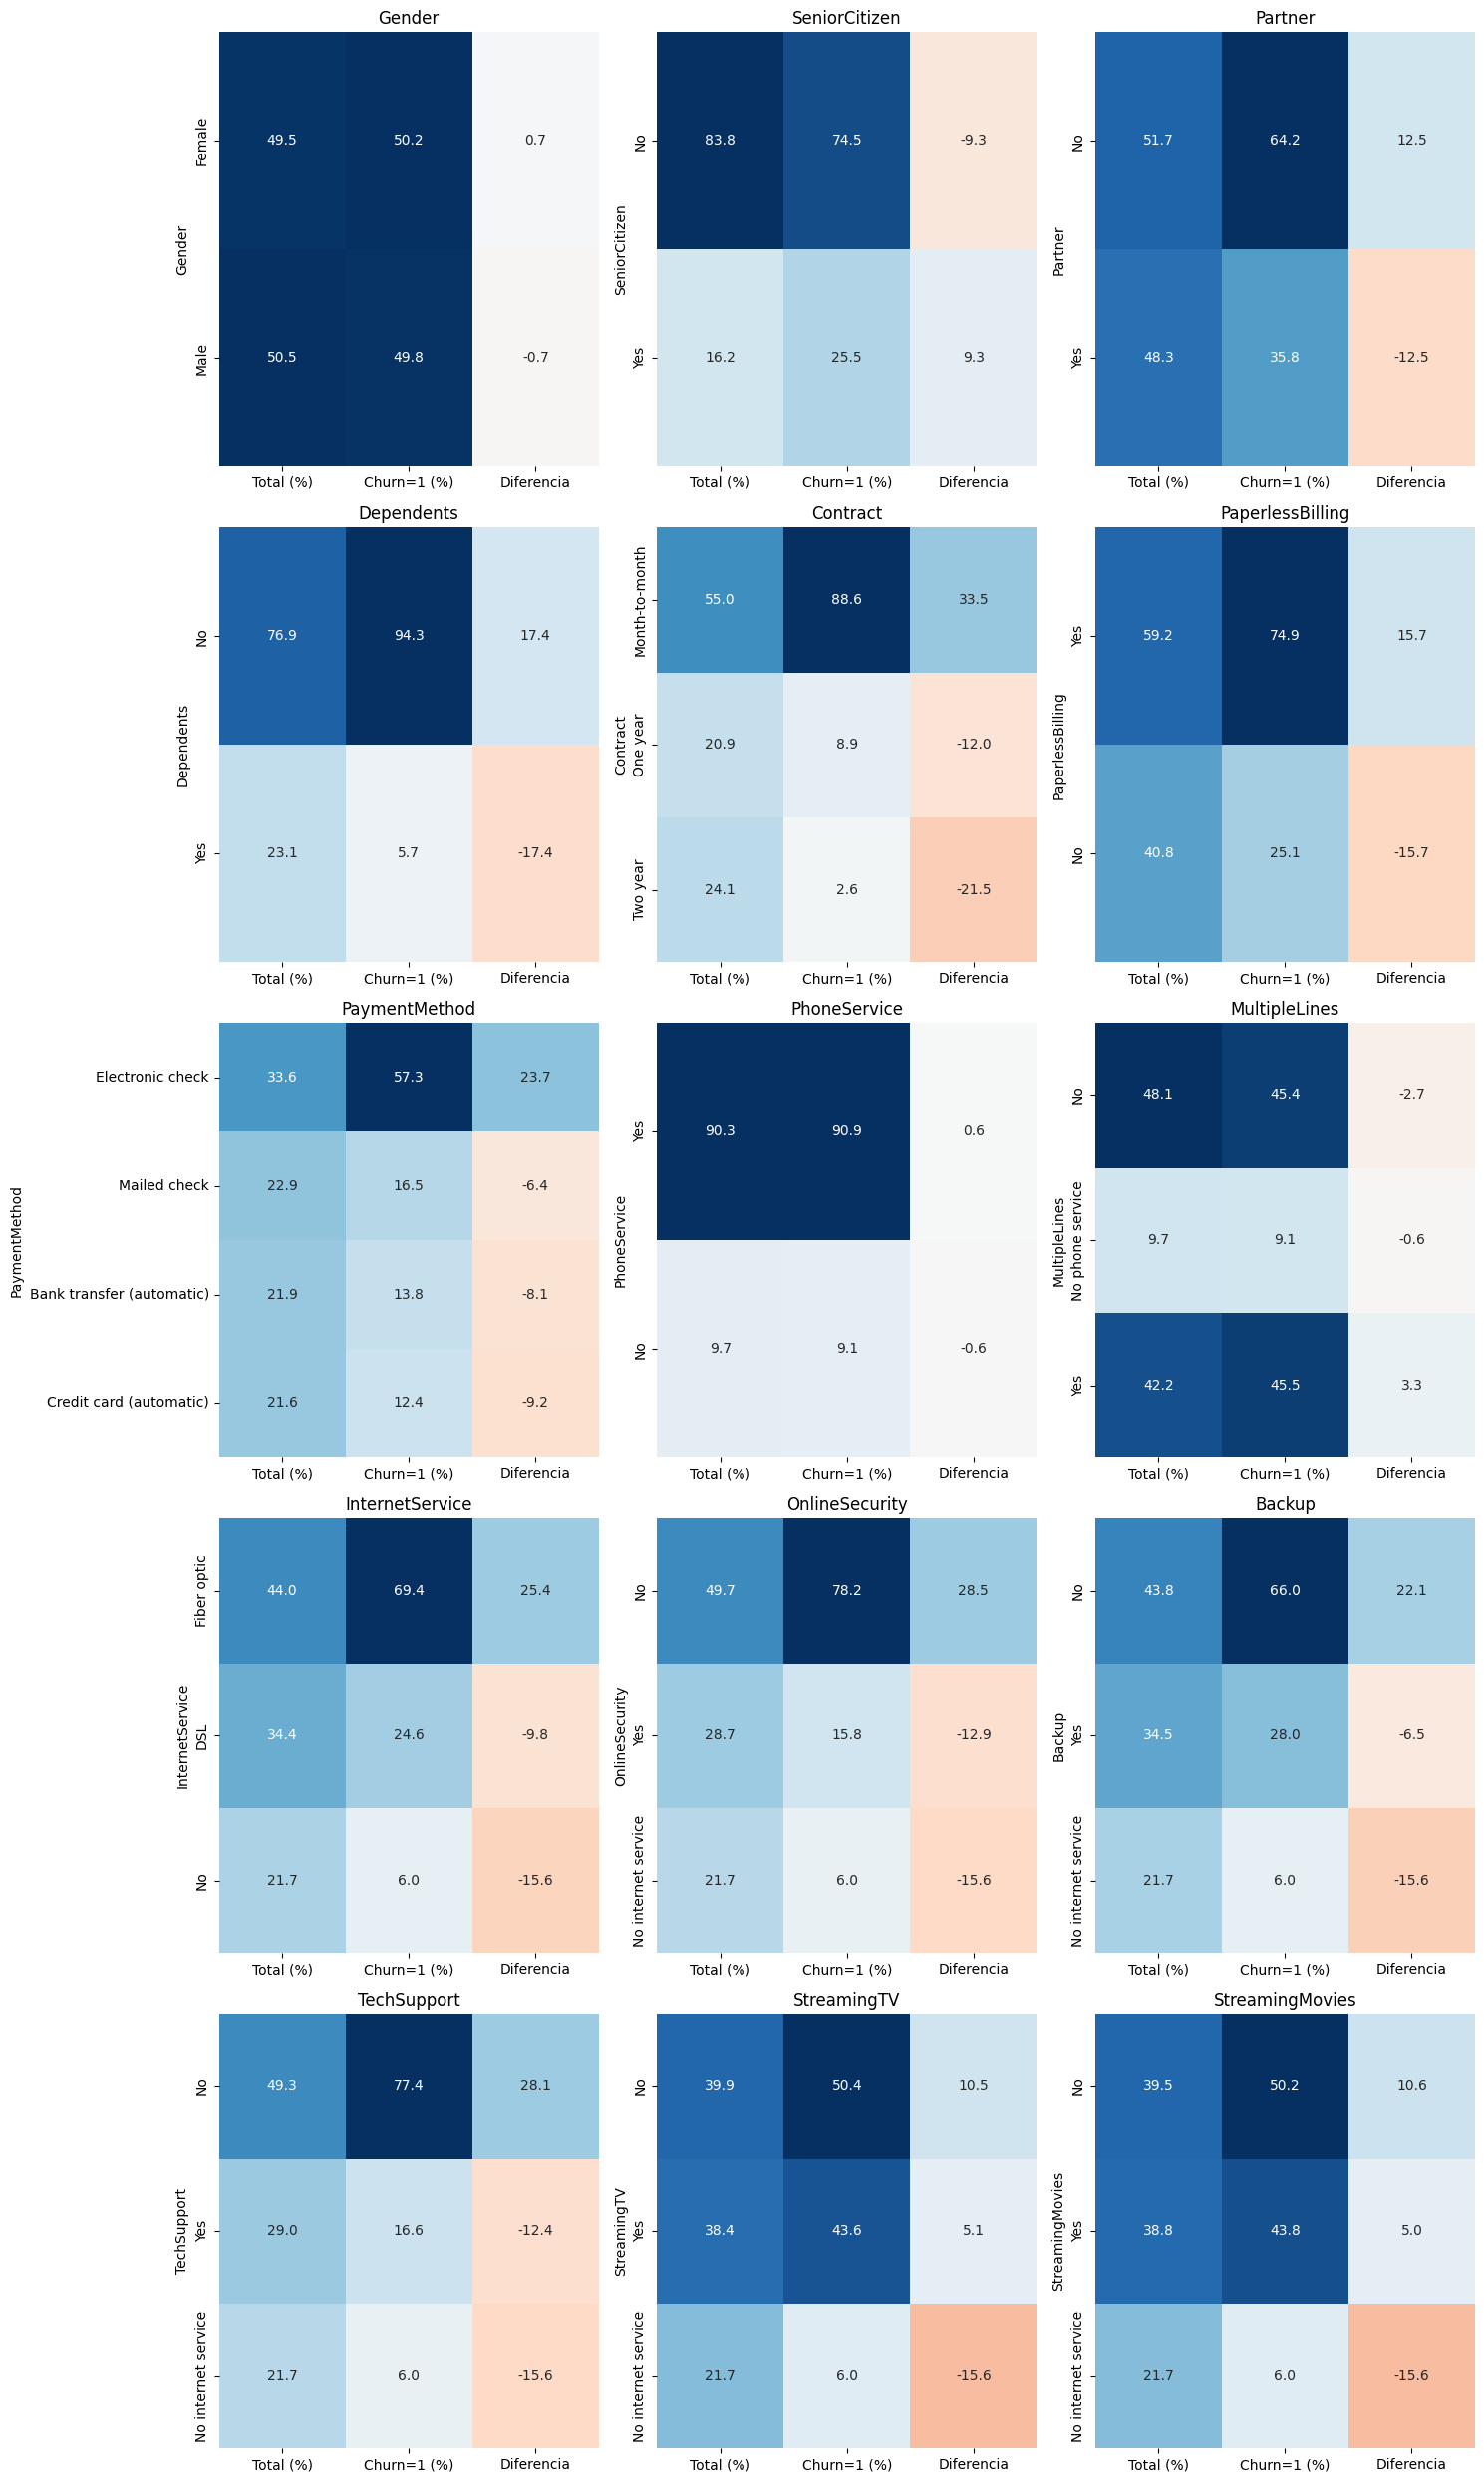

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df_churn1 = df[df['churn'] == 1]

n_cols = 3
n_rows = (len(columnas_categoricas) + 2) // 3

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(columnas_categoricas):

    total = df[col].value_counts(normalize=True) * 100
    churn1 = df_churn1[col].value_counts(normalize=True) * 100

    tabla = pd.DataFrame({
        'Total (%)': total,
        'Churn=1 (%)': churn1
    }).fillna(0)

    tabla['Diferencia'] = tabla['Churn=1 (%)'] - tabla['Total (%)']

    plt.subplot(n_rows, n_cols, i+1)
    sns.heatmap(tabla, annot=True, cmap='RdBu', center=0, fmt=".1f", cbar=False)

    plt.title(col)

plt.tight_layout()
plt.show()

# **ANÁLSIS DEL DATO**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

Separación en variables dependientes e independiente (X e y) y división del conjunto en conjunto de entrenamiento y de test

In [16]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Set de entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de prueba: {X_test.shape[0]} muestras")

Set de entrenamiento: 5634 muestras
Set de prueba: 1409 muestras


Preprocesamiento de variables: las numéricas se escalan y las categóricas se codifican mediante One-Hot Coding

In [17]:
# Identificar columnas por tipo
col_num = ['Tenure', 'MonthlyCharges', 'TotalCharges']
col_cat = [c for c in X.columns if c not in col_num]

# Definir el transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_num),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), col_cat)
    ])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

Aplicar el método SMOTE para tratar el desbalanceo de clases: generar muestras sintéticas para igualar el número de muestras de ambas clases

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_prep, y_train)

print(f"Distribución original Churn: {np.bincount(y_train)}")
print(f"Distribución tras SMOTE: {np.bincount(y_train_res)}")

Distribución original Churn: [4139 1495]
Distribución tras SMOTE: [4139 4139]


GridSearchCV para escoger hiperparámetros (validación cruzada)

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Configuración hiperparámetros
param_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

param_tree = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10,  None],
    'min_samples_leaf': [1, 2]
}

# Búsqueda
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_log, cv=5, scoring='roc_auc', n_jobs=-1)
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_tree, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf  = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='roc_auc', n_jobs=-1)


Entrenamiento de los modelos

In [20]:
grid_log.fit(X_train_res, y_train_res)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [21]:
grid_tree.fit(X_train_res, y_train_res)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [22]:
grid_rf.fit(X_train_res, y_train_res)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_leaf': [1, 2],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [23]:
modelos = {
    "Regresión Logística": grid_log.best_estimator_,
    "Árbol de Decisión": grid_tree.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}


In [24]:
mejores_params = {
    "Regresión Logística": grid_log.best_params_,
    "Árbol de Decisión": grid_tree.best_params_,
    "Random Forest": grid_rf.best_params_
}

import pandas as pd
df_params = pd.DataFrame.from_dict(mejores_params, orient='index')
display(df_params)

,C,solver,criterion,max_depth,min_samples_split,min_samples_leaf,n_estimators
Regresión Logística,10.0,lbfgs,NaN,NaN,NaN,NaN,NaN
Árbol de Decisión,NaN,NaN,entropy,10.0,10.0,NaN,NaN
Random Forest,NaN,NaN,NaN,NaN,NaN,1.0,200.0


Evaluación y comparativa de los modelos

===== COMPARATIVA DE MODELOS (MÉTRICAS BALANCEADAS) =====


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Regresión Logística,0.743790,0.705397,0.753030,0.711712,0.846682
1,Árbol de Decisión,0.748048,0.694135,0.725192,0.703144,0.810556
2,Random Forest,0.781405,0.719827,0.720575,0.720199,0.837282


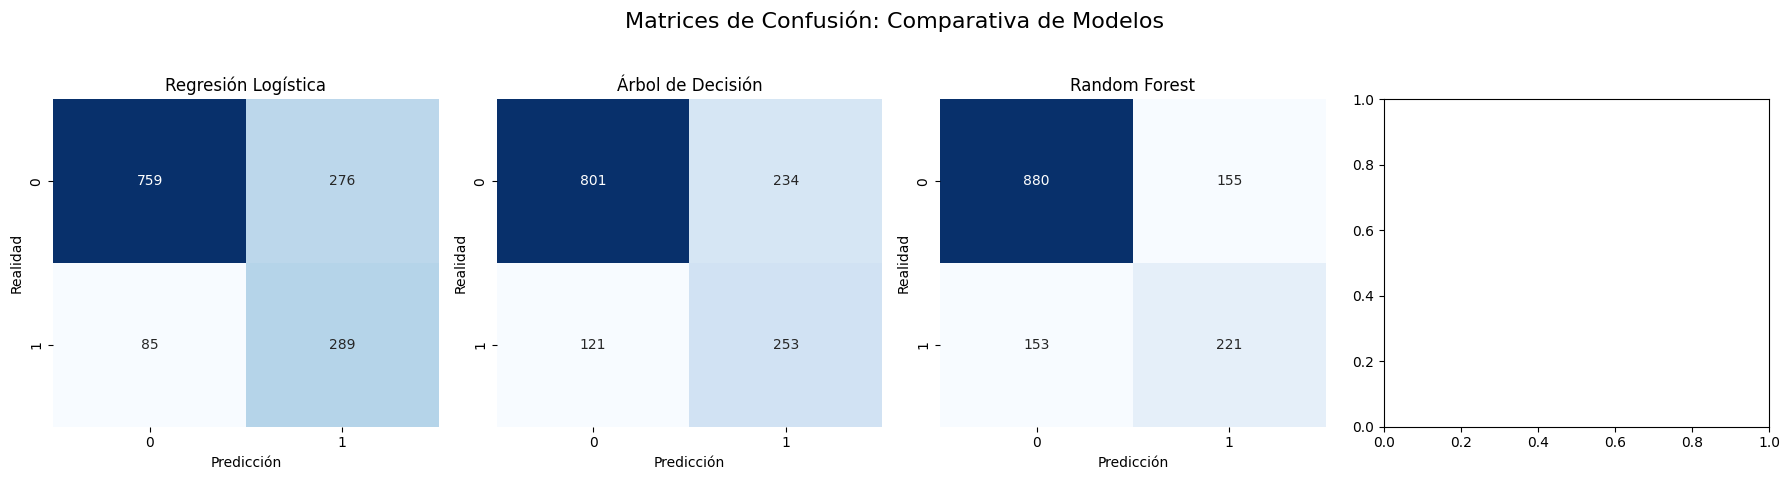

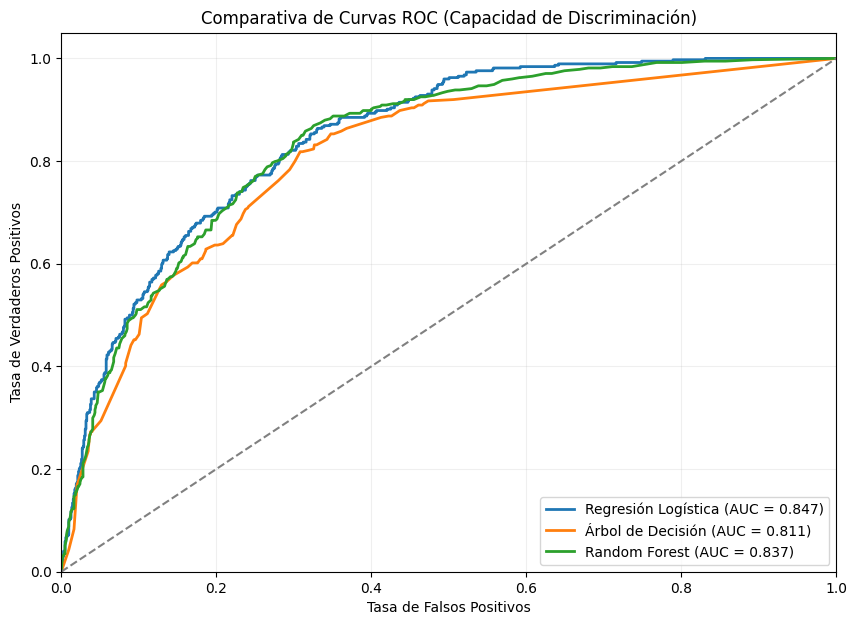

In [25]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
resultados_globales = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_prep)
    y_prob = modelo.predict_proba(X_test_prep)[:, 1]

    resultados_globales.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

df_resumen = pd.DataFrame(resultados_globales)
print("===== COMPARATIVA DE MODELOS (MÉTRICAS BALANCEADAS) =====")
display(df_resumen.style.highlight_max(axis=0, color='lightgreen'))

# Matrices confusión
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Matrices de Confusión: Comparativa de Modelos', fontsize=16)

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_test_prep)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(nombre)
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Realidad')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Cruvas AU-ROC
plt.figure(figsize=(10, 7))

for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparativa de Curvas ROC (Capacidad de Discriminación)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

Variables determinantes a la hora de abandonar la compañía

In [26]:
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out()
num_features = ['Tenure', 'MonthlyCharges', 'TotalCharges'] # Ajusta según tus columnas numéricas
all_features = np.concatenate([num_features, cat_features])

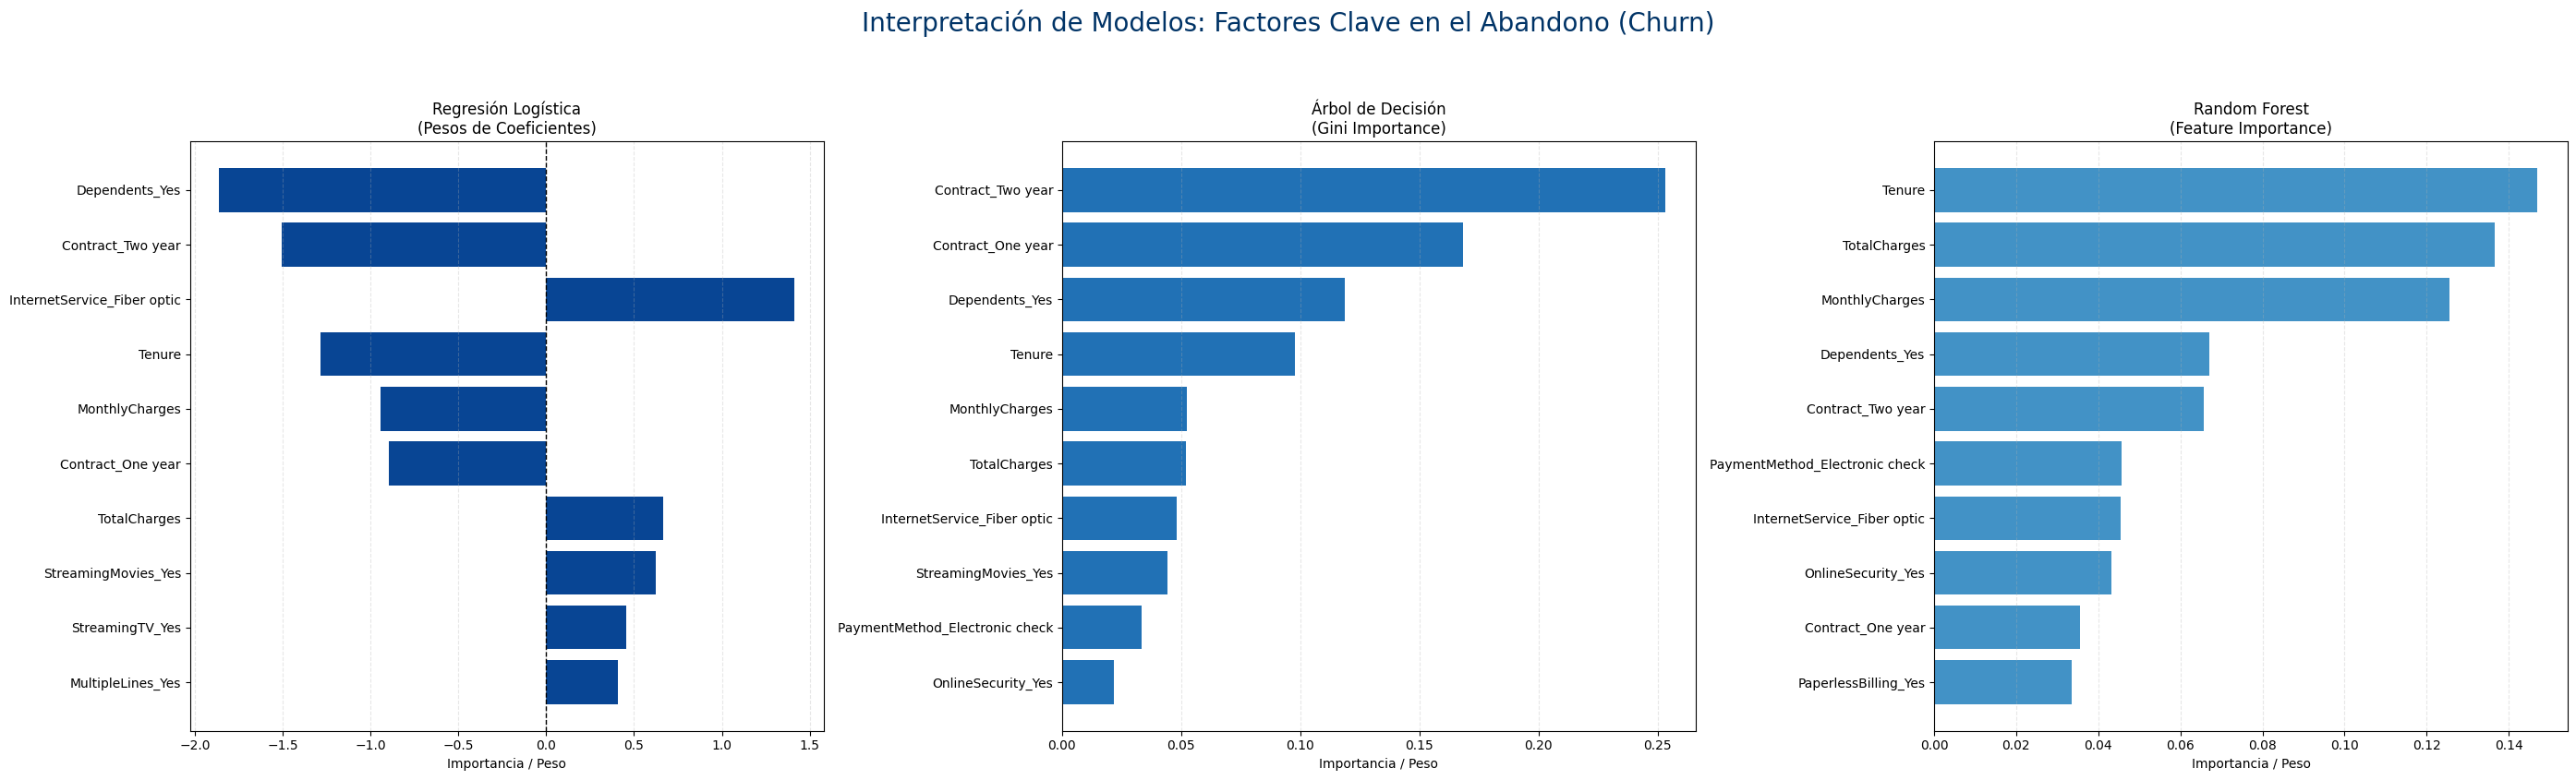

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la figura
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
fig.suptitle('Interpretación de Modelos: Factores Clave en el Abandono (Churn)', fontsize=20, color='#003366', y=1.05)

# Paleta de colores en escala de azules
colores_azul = ['#084594', '#2171b5', '#4292c6', '#6baed6']

# 1. REGRESIÓN LOGÍSTICA (Coeficientes)
# Usamos el modelo optimizado dentro del diccionario modelos_opt
coefs = modelos["Regresión Logística"].coef_[0]
indices_log = np.argsort(np.abs(coefs))[-10:] # Top 10 por impacto absoluto

axes[0].barh(range(10), coefs[indices_log], color=colores_azul[0])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([all_features[i] for i in indices_log])
axes[0].set_title('Regresión Logística\n(Pesos de Coeficientes)')
axes[0].axvline(0, color='black', lw=1, linestyle='--')

# 2. ÁRBOL DE DECISIÓN (Importancia)
imp_tree = modelos["Árbol de Decisión"].feature_importances_
indices_tree = np.argsort(imp_tree)[-10:]

axes[1].barh(range(10), imp_tree[indices_tree], color=colores_azul[1])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([all_features[i] for i in indices_tree])
axes[1].set_title('Árbol de Decisión\n(Gini Importance)')

# 3. RANDOM FOREST (Importancia)
imp_rf = modelos["Random Forest"].feature_importances_
indices_rf = np.argsort(imp_rf)[-10:]

axes[2].barh(range(10), imp_rf[indices_rf], color=colores_azul[2])
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([all_features[i] for i in indices_rf])
axes[2].set_title('Random Forest\n(Feature Importance)')


# Ajustes finales de estilo
for ax in axes:
    ax.set_xlabel('Importancia / Peso')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()